# Visualizing the Loss Landscape of Neural Nets

In this lab we reproduce (in simplified form) key results from the paper:

> Li, Xu, Taylor, Studer, Goldstein. *Visualizing the Loss Landscape of Neural Nets.* NeurIPS 2018.

We will train small ResNet-style models on FashionMNIST with and without skip connections, then implement the paper's visualization methods to see how architecture choices shape the loss landscape.

### Recommended Reading
1. [Visualizing the Loss Landscape of Neural Nets (arXiv)](https://arxiv.org/abs/1712.09913)
2. [loss-landscape GitHub repository](https://github.com/tomgoldstein/loss-landscape) — authors' original code
3. [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385) — the original ResNet paper

## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from tqdm.auto import tqdm

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cuda


## 2. Data

We use [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist) — 28x28 grayscale images of clothing items (10 classes). It is harder than MNIST but trains much faster than CIFAR-10 due to the single channel and smaller spatial size.

We train on a **10K subset** to keep training fast on CPU (~30s per model). For loss landscape evaluation we use a separate **1K subset** of the test set.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)


def get_subset_loader(dataset, num_samples: int, batch_size: int = 256, shuffle: bool = False) -> torch.utils.data.DataLoader:
    """Create a DataLoader from a random subset of the dataset."""
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    subset = torch.utils.data.Subset(dataset, indices)
    return torch.utils.data.DataLoader(subset, batch_size=batch_size, shuffle=shuffle, num_workers=2)


TRAIN_SUBSET = 10_000

trainloader = get_subset_loader(trainset, num_samples=TRAIN_SUBSET, batch_size=256, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=512, shuffle=False, num_workers=2)
eval_loader = get_subset_loader(testset, num_samples=1000, batch_size=512)

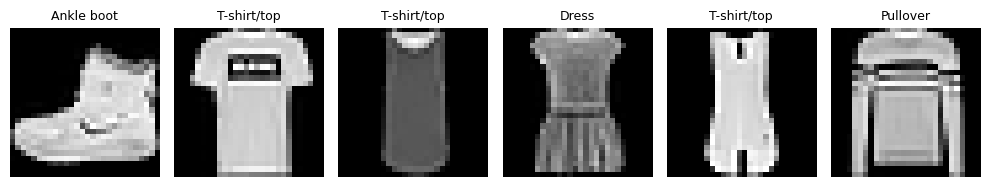

In [4]:
classes = trainset.classes

fig, axes = plt.subplots(1, 6, figsize=(10, 2))

for i, ax in enumerate(axes):
    image, label = trainset[i]

    image = image * 0.3530 + 0.2860

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(classes[label], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Model Architectures

We define a simple ResNet-style architecture with a `use_skip` flag. When `use_skip=True`, the model uses residual connections. When `use_skip=False`, it becomes a plain convolutional network (equivalent to *ResNet-noshort* in the paper).

The architecture has 3 groups of layers with channels `[16, 32, 64]`. The `num_blocks` parameter controls how many basic blocks are in each group: this lets us vary the network depth.

**Depth formula:** total layers = 1 (initial conv) + 2 × sum(num_blocks) + 1 (fc)  
For example: `[3, 3, 3]` → 1 + 18 + 1 = **20 layers**

In [4]:
class BasicBlock(nn.Module):
    """A basic residual block: two 3x3 convolutions with optional skip connection."""

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1, use_skip: bool = True):
        super().__init__()
        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if use_skip and (stride != 1 or in_channels != out_channels):
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_skip:
            out += self.shortcut(x)
        out = self.relu(out)
        return out


class SimpleResNet(nn.Module):
    """
    A simplified ResNet for FashionMNIST.

    Architecture: conv -> [group1 x N] -> [group2 x N] -> [group3 x N] -> avgpool -> fc
    Channels:      16       16               32               64
    """

    def __init__(self, num_blocks: list[int] = [3, 3, 3], num_classes: int = 10, use_skip: bool = True):
        super().__init__()
        self.in_channels = 16
        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(1, 16, 3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(64, num_blocks[2], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, out_channels: int, num_blocks: int, stride: int) -> nn.Sequential:
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, s, self.use_skip))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


model_skip = SimpleResNet(num_blocks=[3, 3, 3], use_skip=True)
model_noskip = SimpleResNet(num_blocks=[3, 3, 3], use_skip=False)

print(f"With skip connections:    {count_parameters(model_skip):,} parameters")
print(f"Without skip connections: {count_parameters(model_noskip):,} parameters")

With skip connections:    272,186 parameters
Without skip connections: 269,434 parameters


## 4. Training

We train both models using SGD with momentum for **10 epochs**.

In [6]:
def train_model(
    model: nn.Module,
    trainloader: torch.utils.data.DataLoader,
    testloader: torch.utils.data.DataLoader,
    epochs: int = 10,
    lr: float = 0.1,
    device: torch.device = device,
) -> tuple[list[float], list[float]]:
    """Train a model and return (train_losses, test_accuracies) per epoch."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.to(device)
    train_losses = []
    test_accs = []

    for epoch in tqdm(range(epochs), desc="Training"):
        model.train()
        running_loss = 0.0
        for inputs, targets in trainloader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        scheduler.step()
        train_losses.append(running_loss / len(trainloader))

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, targets in testloader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        acc = 100.0 * correct / total
        test_accs.append(acc)
        print(f"  Epoch {epoch+1}/{epochs} — Loss: {train_losses[-1]:.4f}, Test Acc: {acc:.2f}%")

    return train_losses, test_accs

In [6]:
print("=== Training model WITH skip connections ===")
losses_skip, accs_skip = train_model(model_skip, trainloader, testloader)

print("\n=== Training model WITHOUT skip connections ===")
losses_noskip, accs_noskip = train_model(model_noskip, trainloader, testloader)

=== Training model WITH skip connections ===


Training:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/10 — Loss: 1.2077, Test Acc: 34.01%
  Epoch 2/10 — Loss: 0.7813, Test Acc: 70.30%
  Epoch 3/10 — Loss: 0.6053, Test Acc: 78.55%
  Epoch 4/10 — Loss: 0.5221, Test Acc: 80.30%
  Epoch 5/10 — Loss: 0.4650, Test Acc: 78.28%
  Epoch 6/10 — Loss: 0.4200, Test Acc: 80.31%
  Epoch 7/10 — Loss: 0.3996, Test Acc: 83.15%
  Epoch 8/10 — Loss: 0.3472, Test Acc: 82.06%
  Epoch 9/10 — Loss: 0.3359, Test Acc: 85.75%
  Epoch 10/10 — Loss: 0.3157, Test Acc: 85.97%

=== Training model WITHOUT skip connections ===


Training:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/10 — Loss: 1.3624, Test Acc: 13.89%
  Epoch 2/10 — Loss: 0.8703, Test Acc: 28.41%
  Epoch 3/10 — Loss: 0.7513, Test Acc: 65.62%
  Epoch 4/10 — Loss: 0.6090, Test Acc: 59.44%
  Epoch 5/10 — Loss: 0.5290, Test Acc: 66.51%
  Epoch 6/10 — Loss: 0.4982, Test Acc: 73.43%
  Epoch 7/10 — Loss: 0.4472, Test Acc: 63.48%
  Epoch 8/10 — Loss: 0.4129, Test Acc: 82.34%
  Epoch 9/10 — Loss: 0.3742, Test Acc: 84.38%
  Epoch 10/10 — Loss: 0.3519, Test Acc: 85.02%


#### zapisuję se modele

In [7]:
import os
from pathlib import Path

SAVE_DIR = Path("./saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

def save_model(model: nn.Module, path: Path):
    torch.save({
        "model_state_dict": model.state_dict(),
    }, path)

save_model(model_skip, SAVE_DIR / "resnet_skip.pth")
save_model(model_noskip, SAVE_DIR / "resnet_noskip.pth")

print(f"Models saved to: {SAVE_DIR.resolve()}")

Models saved to: C:\Users\piotr\UMISI\stochastyczne\lab7\saved_models


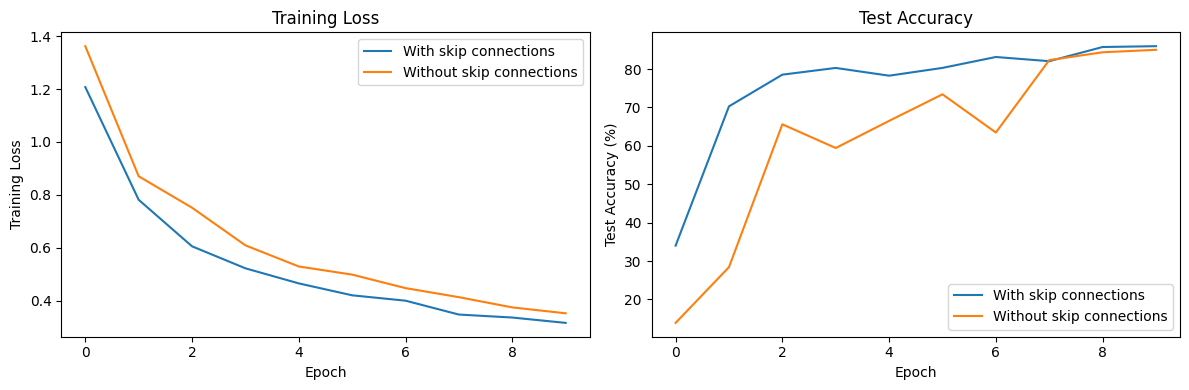

Final test accuracy — with skip: 85.97%, without skip: 85.02%


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses_skip, label="With skip connections")
ax1.plot(losses_noskip, label="Without skip connections")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss")
ax1.set_title("Training Loss")
ax1.legend()

ax2.plot(accs_skip, label="With skip connections")
ax2.plot(accs_noskip, label="Without skip connections")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Test Accuracy (%)")
ax2.set_title("Test Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Final test accuracy — with skip: {accs_skip[-1]:.2f}%, without skip: {accs_noskip[-1]:.2f}%")

## 5. Loss Evaluation Utility

A helper function that computes the average cross-entropy loss of a model on a given dataloader.

In [5]:
@torch.no_grad()
def evaluate_loss(model: nn.Module, dataloader: torch.utils.data.DataLoader, device: torch.device = device) -> float:
    """Compute average cross-entropy loss on the given dataloader."""
    criterion = nn.CrossEntropyLoss()
    model.eval()
    model.to(device)
    total_loss = 0.0
    total_samples = 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        total_loss += loss.item() * targets.size(0)
        total_samples += targets.size(0)
    return total_loss / total_samples

In [6]:
@torch.no_grad()
def get_random_filter_normalized_direction(model: nn.Module) -> list[torch.Tensor]:
    """
    Generate a random direction in parameter space with filter-wise normalization.

    For each parameter tensor theta_{i,j} in the model:
      1. Sample d_{i,j} ~ N(0, 1) with the same shape
      2. Normalize: d_{i,j} <- (d_{i,j} / ||d_{i,j}||) * ||theta_{i,j}||
         - For conv layers (4D), normalize per output filter (dim 0)
         - For other layers, normalize the entire tensor

    Returns:
        A list of tensors, one per model parameter, representing the normalized direction.
    """
    directions = []

    for param in model.parameters():

        d = torch.randn_like(param)
        if param.ndim == 4:
            d_normalized = torch.zeros_like(d)

            for i in range(param.size(0)):
                d_filter = d[i]
                p_filter = param[i]

                d_norm = torch.norm(d_filter)
                p_norm = torch.norm(p_filter)

                if d_norm > 0:
                    d_normalized[i] = d_filter / d_norm * p_norm
                else:
                    d_normalized[i] = torch.zeros_like(d_filter)

            directions.append(d_normalized)

        else:
            d_norm = torch.norm(d)
            p_norm = torch.norm(param)

            if d_norm > 0:
                d = d / d_norm * p_norm
            else:
                d = torch.zeros_like(d)

            directions.append(d)

    return directions

In [9]:
# Sanity check: each direction tensor should have the same shape as the corresponding parameter,
# and for conv filters, each filter's norm should match the parameter's filter norm.
direction = get_random_filter_normalized_direction(model_skip)

for d, (name, p) in zip(direction, model_skip.named_parameters()):
    assert d.shape == p.shape, f"Shape mismatch for {name}: {d.shape} vs {p.shape}"
    if p.dim() == 4:  # Conv layer — check per-filter norm
        for j in range(d.size(0)):
            d_norm = d[j].norm().item()
            p_norm = p[j].norm().item()
            assert abs(d_norm - p_norm) < 1e-5, (
                f"Filter norm mismatch for {name}[{j}]: direction={d_norm:.6f}, param={p_norm:.6f}"
            )

print("All checks passed!")

All checks passed!


In [7]:
def compute_loss_1d(
    model: nn.Module,
    direction: list[torch.Tensor],
    dataloader: torch.utils.data.DataLoader,
    alphas: np.ndarray,
    device: torch.device = device,
) -> list[float]:
    """
    Compute the loss along a 1D direction: f(alpha) = L(theta* + alpha * d).

    Args:
        model: Trained model (parameters = theta*).
        direction: Filter-normalized direction (list of tensors, one per parameter).
        dataloader: DataLoader for loss evaluation.
        alphas: Array of alpha values to evaluate.
        device: Computation device.

    Returns:
        List of loss values, one per alpha.
    """
    original_params = [p.detach().clone() for p in model.parameters()]

    losses = []

    for alpha in alphas:
        with torch.no_grad():
            for p, p_orig, d in zip(model.parameters(), original_params, direction):
                p.copy_(p_orig + alpha * d)

        loss = evaluate_loss(model, dataloader, device)
        losses.append(loss)

    with torch.no_grad():
        for p, p_orig in zip(model.parameters(), original_params):
            p.copy_(p_orig)

    return losses

#### wczytuje wytrenowane modele co se wcześniej zapisałem

In [8]:
from pathlib import Path

SAVE_DIR = Path("./saved_models")

def load_saved_model(path: str, use_skip: bool, device: torch.device = device) -> nn.Module:
    model = SimpleResNet(num_blocks=[3, 3, 3], use_skip=use_skip)
    
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    
    model.to(device)
    model.eval()
    return model

model_skip = load_saved_model(SAVE_DIR / "resnet_skip.pth", use_skip=True)
model_noskip = load_saved_model(SAVE_DIR / "resnet_noskip.pth", use_skip=False)

print("Models loaded.")

Models loaded.


In [14]:
alphas = np.linspace(-1, 1, 21)

dir_skip = get_random_filter_normalized_direction(model_skip)
dir_noskip = get_random_filter_normalized_direction(model_noskip)

print("Computing 1D landscape for model WITH skip connections...")
losses_1d_skip = compute_loss_1d(model_skip, dir_skip, eval_loader, alphas)

print("Computing 1D landscape for model WITHOUT skip connections...")
losses_1d_noskip = compute_loss_1d(model_noskip, dir_noskip, eval_loader, alphas)

Computing 1D landscape for model WITH skip connections...
Computing 1D landscape for model WITHOUT skip connections...


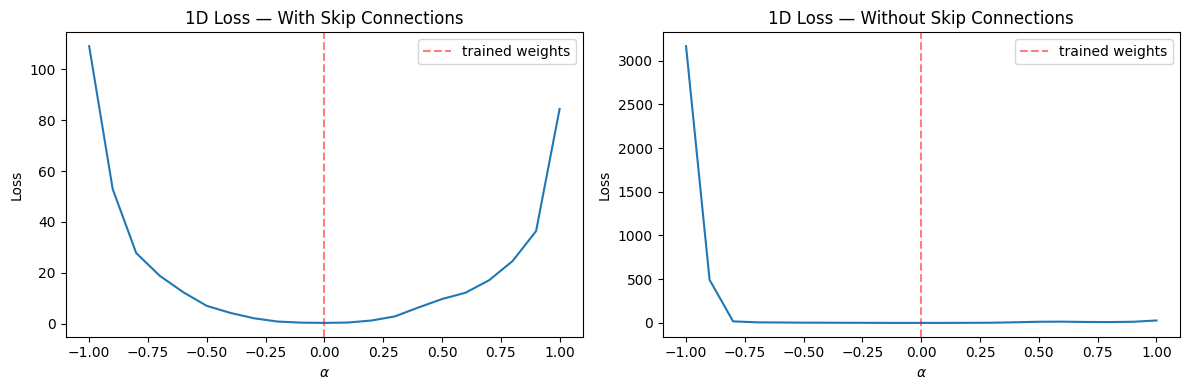

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(alphas, losses_1d_skip)
ax1.axvline(0, color="red", linestyle="--", alpha=0.5, label="trained weights")
ax1.set_xlabel(r"$\alpha$")
ax1.set_ylabel("Loss")
ax1.set_title("1D Loss — With Skip Connections")
ax1.legend()

ax2.plot(alphas, losses_1d_noskip)
ax2.axvline(0, color="red", linestyle="--", alpha=0.5, label="trained weights")
ax2.set_xlabel(r"$\alpha$")
ax2.set_ylabel("Loss")
ax2.set_title("1D Loss — Without Skip Connections")
ax2.legend()

plt.tight_layout()
plt.show()

In [9]:
def compute_loss_2d(
    model: nn.Module,
    direction1: list[torch.Tensor],
    direction2: list[torch.Tensor],
    dataloader: torch.utils.data.DataLoader,
    alphas: np.ndarray,
    betas: np.ndarray,
    device: torch.device = device,
) -> np.ndarray:
    """
    Compute loss on a 2D grid: f(alpha, beta) = L(theta* + alpha * d1 + beta * d2).

    Args:
        model: Trained model (parameters = theta*).
        direction1: First filter-normalized direction (delta).
        direction2: Second filter-normalized direction (eta).
        dataloader: DataLoader for loss evaluation.
        alphas: Array of alpha values (x-axis).
        betas: Array of beta values (y-axis).
        device: Computation device.

    Returns:
        2D numpy array of shape (len(betas), len(alphas)) with loss values.
    """
    # raise NotImplementedError("Implement 2D loss landscape computation.")
    original_params = [p.detach().clone() for p in model.parameters()]
    grid = np.zeros((len(betas), len(alphas)), dtype=np.float32)

    for i, beta in enumerate(tqdm(betas, desc="2D landscape rows")):
        for j, alpha in enumerate(alphas):
            with torch.no_grad():
                for p, p_orig, d1, d2 in zip(
                    model.parameters(),
                    original_params,
                    direction1,
                    direction2,
                ):
                    p.copy_(p_orig + alpha * d1 + beta * d2)

            grid[i, j] = evaluate_loss(model, dataloader, device)

    with torch.no_grad():
        for p, p_orig in zip(model.parameters(), original_params):
            p.copy_(p_orig)

    return grid

In [11]:
GRID_SIZE = 21  # increase to 21 for smoother plots if you have a GPU ( tak, mam GPU )
grid_points = np.linspace(-1, 1, GRID_SIZE)

dir1_skip = get_random_filter_normalized_direction(model_skip)
dir2_skip = get_random_filter_normalized_direction(model_skip)

dir1_noskip = get_random_filter_normalized_direction(model_noskip)
dir2_noskip = get_random_filter_normalized_direction(model_noskip)

print(f"Computing 2D landscape ({GRID_SIZE}x{GRID_SIZE} grid)...")

print("  Model WITH skip connections...")
grid_skip = compute_loss_2d(model_skip, dir1_skip, dir2_skip, eval_loader, grid_points, grid_points)

print("  Model WITHOUT skip connections...")
grid_noskip = compute_loss_2d(model_noskip, dir1_noskip, dir2_noskip, eval_loader, grid_points, grid_points)

Computing 2D landscape (21x21 grid)...
  Model WITH skip connections...


2D landscape rows:   0%|          | 0/21 [00:00<?, ?it/s]

  Model WITHOUT skip connections...


2D landscape rows:   0%|          | 0/21 [00:00<?, ?it/s]

#### zapisuję sobie, bo sie strasznie długo mieliło

In [12]:
np.save("grid_points_21.npy", grid_points)
np.save("grid_skip_21.npy", grid_skip)
np.save("grid_noskip_21.npy", grid_noskip)

print("Saved 2D grids.")

Saved 2D grids.


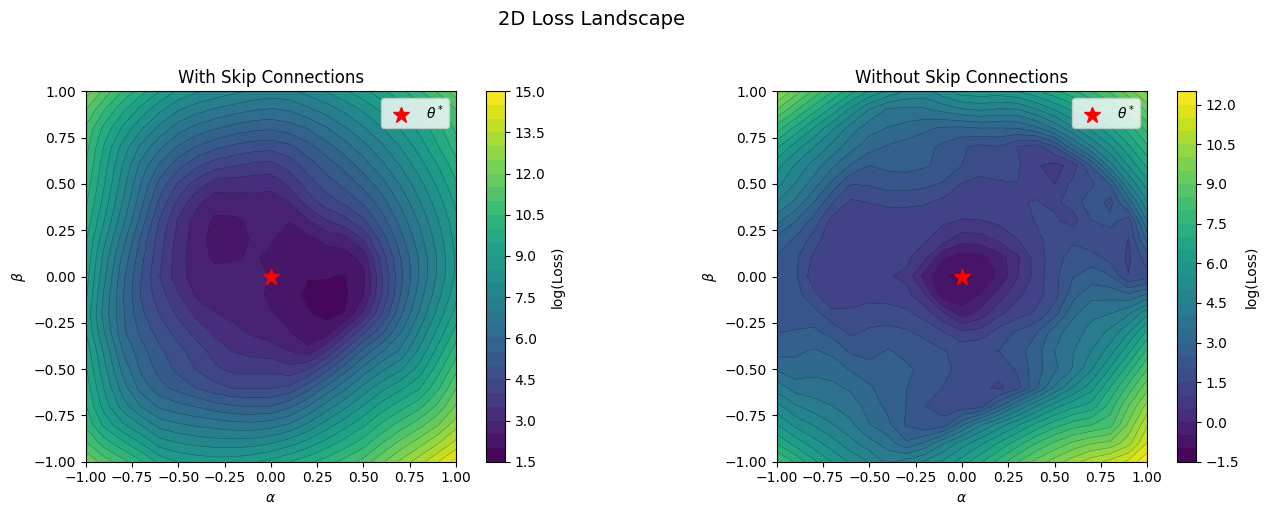

In [13]:
def plot_loss_contour(
    grid: np.ndarray, alphas: np.ndarray, betas: np.ndarray, title: str, ax=None, vmax: float | None = None,
) -> None:
    """Plot a 2D loss contour map."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    A, B = np.meshgrid(alphas, betas)
    plot_grid = np.log(grid) if grid.min() > 0 else grid
    if vmax is not None:
        plot_grid = np.clip(plot_grid, None, vmax)
    cf = ax.contourf(A, B, plot_grid, levels=30, cmap=cm.viridis)
    ax.contour(A, B, plot_grid, levels=30, colors="k", linewidths=0.3, alpha=0.5)
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.plot(0, 0, "r*", markersize=12, label=r"$\theta^*$")
    ax.legend()
    plt.colorbar(cf, ax=ax, label="log(Loss)")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

vmax = max(np.log(grid_skip).max(), np.log(grid_noskip).max())
plot_loss_contour(grid_skip, grid_points, grid_points, "With Skip Connections", ax=ax1, vmax=vmax)
plot_loss_contour(grid_noskip, grid_points, grid_points, "Without Skip Connections", ax=ax2, vmax=vmax)

plt.suptitle("2D Loss Landscape", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Exercise 4: Comparison and Analysis

**Tasks:**

1. **Compare the 1D plots**: How do the curves differ between the model with skip connections and the one without? Which has a wider "valley" around the minimum?

2. **Compare the 2D contour plots**: Describe the shape differences. Are the contours more circular or elongated? Does the minimum appear sharper or flatter?

3. **Normalized vs. unnormalized directions**: Generate a direction **without** filter normalization (just `torch.randn_like(p)` for each parameter) and create the same 1D plot.

4. **Relate to training**: How do the landscape differences connect to the training curves you observed (loss convergence speed, final test accuracy)?

#### kod do 4.3

In [16]:
@torch.no_grad()
def get_random_unnormalized_direction(model: nn.Module) -> list[torch.Tensor]:

    return [torch.randn_like(p) for p in model.parameters()]

In [17]:
alphas = grid_points

dir_skip_unnorm = get_random_unnormalized_direction(model_skip)
dir_noskip_unnorm = get_random_unnormalized_direction(model_noskip)

print("Computing 1D landscape with UNNORMALIZED direction for model WITH skip connections...")
losses_1d_skip_unnorm = compute_loss_1d(model_skip, dir_skip_unnorm, eval_loader, alphas)

print("Computing 1D landscape with UNNORMALIZED direction for model WITHOUT skip connections...")
losses_1d_noskip_unnorm = compute_loss_1d(model_noskip, dir_noskip_unnorm, eval_loader, alphas)

Computing 1D landscape with UNNORMALIZED direction for model WITH skip connections...
Computing 1D landscape with UNNORMALIZED direction for model WITHOUT skip connections...


In [18]:
if "alphas" not in globals():
    alphas = grid_points

if "losses_1d_skip" not in globals() or "losses_1d_noskip" not in globals():
    print("Normalized 1D losses not found. Computing them now...")

    dir_skip = get_random_filter_normalized_direction(model_skip)
    dir_noskip = get_random_filter_normalized_direction(model_noskip)

    print("Computing 1D landscape with FILTER-NORMALIZED direction for model WITH skip connections...")
    losses_1d_skip = compute_loss_1d(model_skip, dir_skip, eval_loader, alphas)

    print("Computing 1D landscape with FILTER-NORMALIZED direction for model WITHOUT skip connections...")
    losses_1d_noskip = compute_loss_1d(model_noskip, dir_noskip, eval_loader, alphas)
else:
    print("Normalized 1D losses already exist.")

Normalized 1D losses not found. Computing them now...
Computing 1D landscape with FILTER-NORMALIZED direction for model WITH skip connections...
Computing 1D landscape with FILTER-NORMALIZED direction for model WITHOUT skip connections...


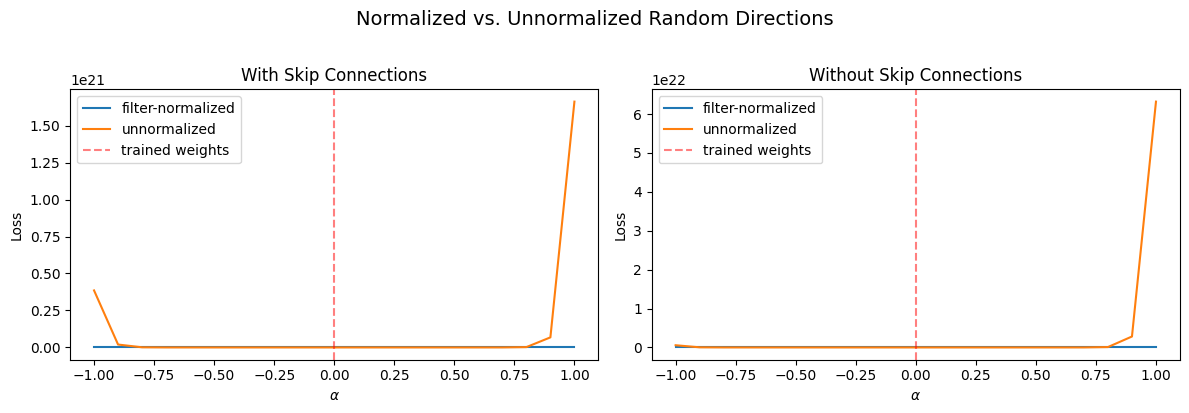

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(alphas, losses_1d_skip, label="filter-normalized")
ax1.plot(alphas, losses_1d_skip_unnorm, label="unnormalized")
ax1.axvline(0, color="red", linestyle="--", alpha=0.5, label="trained weights")
ax1.set_xlabel(r"$\alpha$")
ax1.set_ylabel("Loss")
ax1.set_title("With Skip Connections")
ax1.legend()

ax2.plot(alphas, losses_1d_noskip, label="filter-normalized")
ax2.plot(alphas, losses_1d_noskip_unnorm, label="unnormalized")
ax2.axvline(0, color="red", linestyle="--", alpha=0.5, label="trained weights")
ax2.set_xlabel(r"$\alpha$")
ax2.set_ylabel("Loss")
ax2.set_title("Without Skip Connections")
ax2.legend()

plt.suptitle("Normalized vs. Unnormalized Random Directions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [20]:
np.save("alphas_1d.npy", alphas)

np.save("losses_1d_skip_norm.npy", losses_1d_skip)
np.save("losses_1d_noskip_norm.npy", losses_1d_noskip)

np.save("losses_1d_skip_unnorm.npy", losses_1d_skip_unnorm)
np.save("losses_1d_noskip_unnorm.npy", losses_1d_noskip_unnorm)

print("Saved 1D losses.")

Saved 1D losses.


### Exercise 4: Comparison and Analysis

1. **Compare the 1D plots**: How do the curves differ between the model with skip connections and the one without? Which has a wider "valley" around the minimum?

Na wykresach 1D widać, że model ze skip connections ma dużo gładszą i szerszą dolinę wokół minimum. Loss rośnie stopniowo, gdy oddalamy się od wytrenowanych wag. Model bez skipów wygląda gorzej, szczególnie po lewej stronie loss wywala mocno w kosmos, więc minimum jest bardziej kruche i mniej stabilne.

2. **Compare the 2D contour plots**: Describe the shape differences. Are the contours more circular or elongated? Does the minimum appear sharper or flatter?


Na wykresach 2D model ze skip connections też wygląda lepiej. Kontury są bardziej regularne, gładsze i bardziej "okrągłe", a minimum wygląda na bardziej płaskie. Model bez skipów ma bardziej pocięte i nieregularne kontury, więc loss landscape jest bardziej poszarpany. W skrócie: vanilla model jest bardziej wrażliwy na kierunek, w którym ruszamy parametry.

3. **Normalized vs. unnormalized directions**: Generate a direction **without** filter normalization (just `torch.randn_like(p)` for each parameter) and create the same 1D plot.

Dla kierunków bez normalizacji użyłem zwykłego `torch.randn_like(p)` dla każdego parametru. Wykres 1D dla unnormalized directions pokazuje, że loss potrafi wywalić do absurdalnych wartości rzędu `1e21` albo `1e22`. Przez to znormalizowana krzywa praktycznie znika na wykresie. To pokazuje, po co jest filter normalization - bez niej wykres bardziej pokazuje losową skalę perturbacji niż sensowną geometrię loss landscape.



4. **Relate to training**: How do the landscape differences connect to the training curves you observed (loss convergence speed, final test accuracy)?

To pasuje do treningu. Model ze skip connections trenował się stabilniej i skończył z trochę lepszym accuracy. Model bez skipów doszedł do podobnego wyniku, ale jego landscape wygląda ostrzej i bardziej nieregularnie, więc optymalizacja jest mniej stabilna. Czyli klasycznie: skip connections robią robotę, a vanilla model trochę bardziej jedzie na farcie i modlitwie.

## Discussion Questions

1. The paper claims that skip connections "prevent the explosion of non-convexity" as depth increases. Based on your experiments, do you agree? What mechanism might explain this?

2. Why is filter normalization essential for comparing loss landscapes across different architectures? What would go wrong without it?

3. The paper found that large-batch training produces sharper minima and worse generalization. How could you test this using the tools you've built in this lab?

### Discussion Questions

1. Tak, wyniki raczej wspierają tę tezę. Model ze skip connections miał gładszy loss landscape i bardziej płaskie minimum, a model bez skipów wyglądał bardziej poszarpanie i niestabilnie. Mechanizm jest taki, że skip connections ułatwiają przepływ gradientu przez sieć. Warstwa nie musi uczyć się całej transformacji od zera, tylko może uczyć się poprawki do wejścia. Dzięki temu optymalizacja jest spokojniesza i loss surface nie robi się aż tak dziki wraz z głębokością.

2. Filter normalization jest potrzebne, bo bez niej losowy kierunek może mieć totalnie inną skalę dla różnych warstw i filtrów. Wtedy perturbujemy jedne części modelu dużo mocniej niż inne i wykres przestaje mówić coś sensownego o geometrii minimum. U nas było to dobrze widać: dla unnormalized directions loss wywalił do wartości rzędu `1e21` albo `1e22`, więc wykres był praktycznie zdominowany przez skalę perturbacji. Bez normalizacji porównanie architektur byłoby trochę z bez sensu, bo mierzymy bardziej przypadkową skalę wag niż faktyczną ostrość minimum.

3. Można to przetestować trenując tę samą architekturę dwa razy, z tymi samymi hiperparametrami, ale różnymi batch size, np. `64` i `1024`. Potem dla obu modeli liczymy 1D i 2D loss landscape tymi samymi narzędziami co tutaj. Jeśli paper ma rację, model trenowany dużym batchem powinien mieć ostrzejsze minimum - węższą dolinę w 1D i bardziej strome kontury w 2D. Do tego można porównać test accuracy: jeśli duży batch generalizuje gorzej, powinien mieć podobny albo niższy wynik na teście mimo dobrego treningu.